# Starting with a Simple Example: Digits Data from sklearn
Let's start our adventure into convolutional networks with a simple example of the digits dataset. This was not always such a simple example, but modern day computing power and open source tools has made it a significantly more tractable problem. 

Note that we will not be using the `tf.data` format for these example since they are sufficiently small enough to work with. 

Moreover, we will employ the sequential API in keras, which assumes that the output from the previous operation becomes the input to the next operation. Thus, we can build feedforward networks by simply adding operations in a list. Specifically, we will use the `model.add( )` function.

In [1]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK']='True'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK']='True'

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

import numpy as np
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

print('System', sys.version)
print('Torch version:',torch.__version__)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

if torch.cuda.is_available(): device = torch.device("cuda")
elif torch.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")
print(f'Using {device}')

System 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:01) [Clang 20.1.8 ]
Torch version: 2.13.0
CUDA available: False
MPS available: True
MPS built: True
Using mps


In [2]:
class OneHotDataset(Dataset):
    def __init__(self, features, labels, num_classes):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.num_classes = num_classes

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # One-hot encode label: shape becomes (num_classes,)
        y = F.one_hot(self.labels[idx], num_classes=self.num_classes).float()
        return self.features[idx], y
        
def load_digits():
    
    digits = datasets.load_digits()
    
    # NORMALIZATION, VERY IMPORTANT, Like we showed in Neural Network Lab
    X = digits.data.astype(np.float32)/16.0 - 0.5
    y = digits.target.astype(np.int32)
    
    X = X.reshape((X.shape[0],1,8,8)) # reshape as images
    # the image data has been resized to (samples, image_rows, image_cols, image_channels)
    
    # Split it into train / test subsets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # and one hot encoding the output values
    NUM_CLASSES = 10

    ds_train = DataLoader(OneHotDataset(X_train, y_train, NUM_CLASSES), 
                          batch_size=64, shuffle=True, 
                          pin_memory=False,      # Set False on MPS (unified memory handles copies directly)
                         ) 
    
    ds_test = DataLoader(OneHotDataset(X_test, y_test, NUM_CLASSES), 
                         batch_size=64, shuffle=False, 
                          pin_memory=False,      # Set False on MPS (unified memory handles copies directly)
                        ) 

    return ds_train, ds_test

train_loader, test_loader = load_digits()


Image size: torch.Size([1, 8, 8]) , Classes: 10


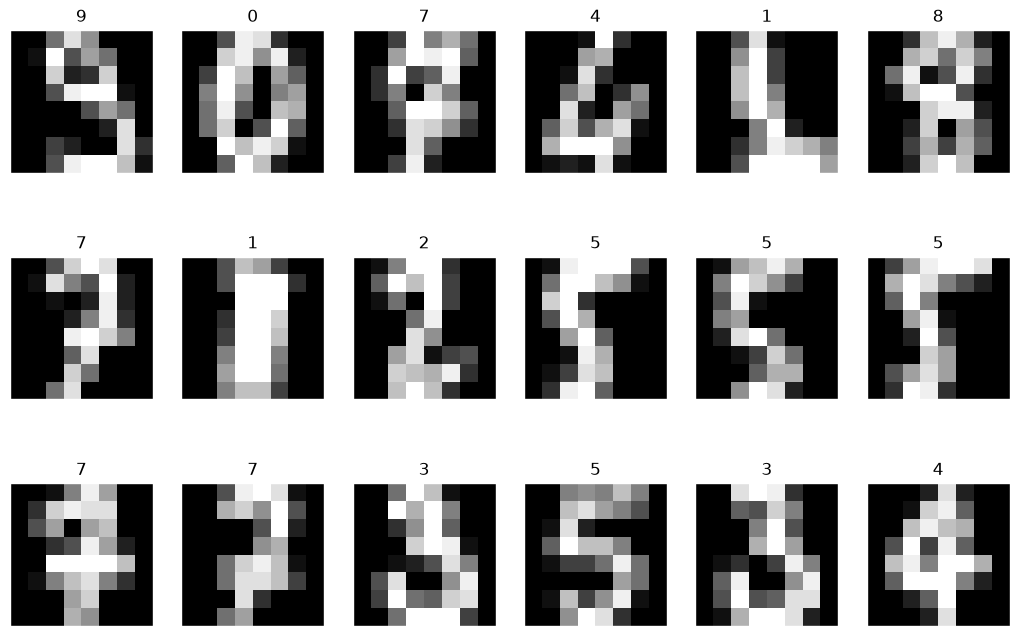

In [3]:
# What do these images look like?
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

# a helper plotting function
def plot_gallery(images, titles, h, w, n_row=3, n_col=6):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.7 * n_col, 2.3 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].squeeze(), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

img_sample, label_sample = next(iter(train_loader))

NUM_CLASSES = label_sample.shape[1] # get one hot encoding dimension for the number of classes
img_wh = img_sample[0].shape[0] # get the width and height for the image
print('Image size:',img_sample[0].shape,', Classes:',NUM_CLASSES)

# provide some image for plotting as a gallery using this batch
plot_gallery(img_sample.numpy(), np.argmax(label_sample.numpy(),axis=1), 8, 8) # defaults to showing a 3 by 6 subset of the images



____
# A Simple ConvNet Versus a Raw Pixel Input MLP
What if we could just let the weights of the convolution be found through neural network training methods? Of course, we can! Let's do one example with a simple CNN architecture and compare it to the performance of a pixel wise MLP.

In general, the flattened images placed through a MLP can be quite accurate (as we have seen in the past). Even so, using convolutional filters and pooling should provide us with some better resilience to small perturbations in the images. 

Note that we need to normalize the input data directly, but we could also do this using torch transforms.

In [4]:
import torch.nn as nn
import torch.optim as optim

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, print_every=10):
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    for epoch in range(epochs): 
        total_loss = 0
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
        history["train_loss"].append(total_loss / len(train_loader))

        total_loss = 0
        predictions = []
        test_labels = []
        model.eval()
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)
                yhat = model(batch_X)
                loss = criterion(yhat, batch_y)
                # Adding the ".data" to the tensor removes operation from autograd tracking
                _, ypreds = torch.max(yhat.data, 1)
                _, batch_y = torch.max(batch_y.data, 1)
                
                predictions.extend(ypreds.cpu())
                test_labels.extend(batch_y.cpu())

                total_loss += loss.item()
            history["test_loss"].append(total_loss / len(test_loader))
            history["test_acc"].append( metrics.accuracy_score(test_labels, predictions) )
            
        if epoch%print_every == 0 or epoch>=epochs-1: 
            # print out some results  
            print(f"Epoch {epoch+1} Loss: {history["train_loss"][-1]:.4f}", end=" ")
            print(f"Test Accuracy: {history["test_acc"][-1]:.4f}")

    return history
    

In [5]:
%%time

# CREATE A BASELINE MLP WITH THREE LAYERS
class ImageMLP(nn.Module):
    def __init__(self, in_features=8*8, hidden_dim=64, num_classes=10):
        super().__init__()
        self.name = 'MLP'
        self.network = nn.Sequential(
            nn.Flatten(), # Flattens [B, C, H, W] -> [B, C*H*W]
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes) # Raw logits output, like from our other examples
        )

    def forward(self, x):
        return self.network(x)

model_mlp = ImageMLP().to(device)
model_mlp

CPU times: user 20.5 ms, sys: 231 ms, total: 252 ms
Wall time: 15.1 ms


ImageMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [6]:
%%time

# CREATE A CNN WITH ONLY ONE CONVOLUTIONAL LAYER AND ONE OUTPUT LAYER

class ImageCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.name = 'SimpleCNN'
        self.feature_extractor = nn.Sequential(
            # Block 1: [B, 1, 8, 8] -> [B, 16, 4, 4]
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: [B, 16, 4, 4] -> [B, 32, 2, 2]
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),                          # [B, 32, 2, 2] -> [B, 32*2*2 = 128]
            nn.Linear(32 * 2 * 2, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)            # Raw logits
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

model_cnn1 = ImageCNN().to(device)
model_cnn1

CPU times: user 14.8 ms, sys: 110 ms, total: 125 ms
Wall time: 7.39 ms


ImageCNN(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [7]:
trainable_params = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f"MLP Trainable parameters: {trainable_params:,}")
trainable_params = sum(p.numel() for p in model_cnn1.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {trainable_params:,}")

MLP Trainable parameters: 6,570
CNN Trainable parameters: 9,258


In [8]:
%%time

criterion = nn.CrossEntropyLoss()

optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=1e-3)
optimizer_cnn = optim.Adam(model_cnn1.parameters(), lr=1e-3)

train_model(model_mlp, train_loader, test_loader, criterion, optimizer_mlp, epochs=80, print_every=10)
train_model(model_cnn1, train_loader, test_loader, criterion, optimizer_cnn, epochs=80, print_every=10)

Epoch 1 Loss: 2.2724 Test Accuracy: 0.2361
Epoch 11 Loss: 0.2403 Test Accuracy: 0.9111
Epoch 21 Loss: 0.1121 Test Accuracy: 0.9472
Epoch 31 Loss: 0.0690 Test Accuracy: 0.9444
Epoch 41 Loss: 0.0495 Test Accuracy: 0.9389
Epoch 51 Loss: 0.0368 Test Accuracy: 0.9583
Epoch 61 Loss: 0.0279 Test Accuracy: 0.9556
Epoch 71 Loss: 0.0208 Test Accuracy: 0.9556
Epoch 80 Loss: 0.0172 Test Accuracy: 0.9556
Epoch 1 Loss: 2.2754 Test Accuracy: 0.5667
Epoch 11 Loss: 0.2094 Test Accuracy: 0.9250
Epoch 21 Loss: 0.0838 Test Accuracy: 0.9583
Epoch 31 Loss: 0.0399 Test Accuracy: 0.9722
Epoch 41 Loss: 0.0195 Test Accuracy: 0.9667
Epoch 51 Loss: 0.0095 Test Accuracy: 0.9778
Epoch 61 Loss: 0.0064 Test Accuracy: 0.9750
Epoch 71 Loss: 0.0042 Test Accuracy: 0.9750
Epoch 80 Loss: 0.0029 Test Accuracy: 0.9778
CPU times: user 4.9 s, sys: 2.47 s, total: 7.37 s
Wall time: 9.02 s


{'train_loss': [2.2753822285196055,
  2.1459910662277886,
  1.8015157139819602,
  1.2762601738390715,
  0.8541125655174255,
  0.5902200470799985,
  0.44163090444129444,
  0.34256571790446405,
  0.2865717138933099,
  0.2472487914821376,
  0.20943169684513754,
  0.18419901929471805,
  0.16174664704695993,
  0.1497355100253354,
  0.1399892390422199,
  0.13120121217292288,
  0.11059217867643936,
  0.10254156767674115,
  0.0985588232136291,
  0.09241046189613965,
  0.08377148648319037,
  0.07555650296094625,
  0.07264336012303829,
  0.06853844452163448,
  0.060532019190166306,
  0.058035243707506554,
  0.05416386922740418,
  0.050578033592066036,
  0.05326882612122142,
  0.040697255455281425,
  0.03985444112154453,
  0.036426243817676666,
  0.033836288823057774,
  0.032228036338220474,
  0.029630526981276016,
  0.030326468606843897,
  0.025261692581293377,
  0.026387720692740833,
  0.023722244912515515,
  0.022441673173528652,
  0.01952418612073297,
  0.018234987297783726,
  0.0199995724808

In [9]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

def compare_models(models, test_loader, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)

    # plot confusion matrices 
    num_plots = len(models)
    i = 1

    for model in models:
        predictions = []
        test_labels = []
        model.eval()
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)
                
                yhat = model(batch_X)
                # Adding the ".data" to the tensor removes operation from autograd tracking
                _, ypreds = torch.max(yhat.data, 1)
                _, batch_y = torch.max(batch_y.data, 1)
                
                predictions.extend(ypreds.cpu())
                test_labels.extend(batch_y.cpu())
    
            acc = metrics.accuracy_score(test_labels,predictions)
    
            cm = metrics.confusion_matrix(test_labels,predictions)
            cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
            
            plt.subplot(1,num_plots,i)
            
            sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels, yticklabels=labels)
            plt.title(f'{model.name}: {acc:.4f}')
            i += 1
    

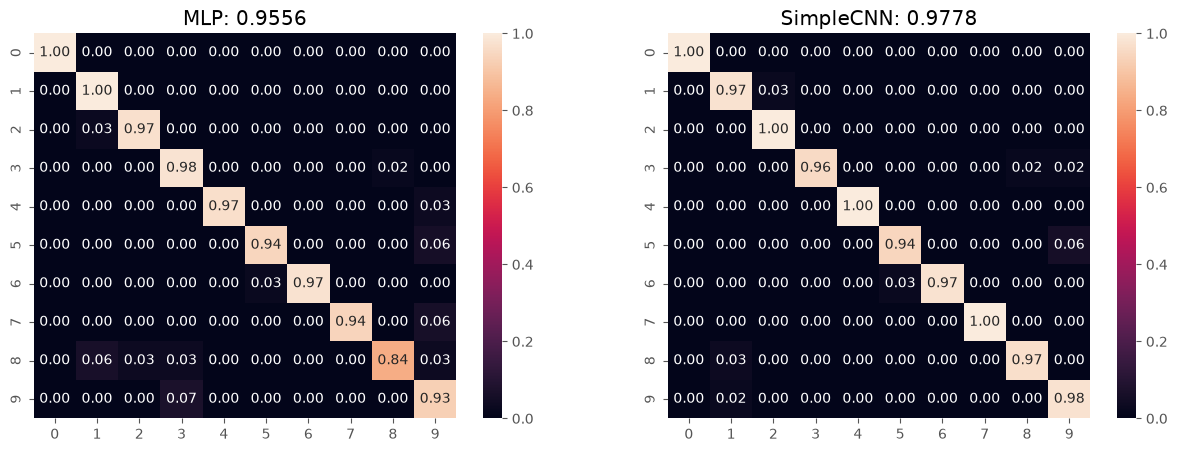

In [10]:
compare_models((model_mlp,model_cnn1), test_loader)

____________
## Defining additional Customizable, CNN Architectures
Now let's define a function to help us create different models to investigate with CNNs. We can customize various pieces such as the kernel size, pooling size, number of layers, filters per layer, and whether to use dropout. 
Now let's try a few different variations, train them and see how they perofrm compared to one another.

In [11]:
%%time

class ImageCNNCustom(nn.Module):
    def __init__(self, input_shape=(1,8,8), filters_per_conv_layer=[32,64], dense_layer_size = 64,
                 use_dropout=False, num_classes=10, name='CustomCNN'):
        super().__init__()
        self.name = name

        in_channels, h, w = input_shape
        layers = []

        # Build Convolutional Blocks dynamically
        current_channels = in_channels
        
        for out_channels in filters_per_conv_layer:
            layers.extend([
                nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            
            if use_dropout:
                layers.append(nn.Dropout2d(p=0.25))
                
            current_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)

        # Run a dummy tensor through feature_extractor to determine Linear layer input size
        with torch.no_grad():
            dummy_input = torch.zeros(1, in_channels, h, w)
            dummy_output = self.feature_extractor(dummy_input)
            flattened_dim = dummy_output.numel()
        
        # Build Classifier Head
        classifier_layers = [
            nn.Flatten(),
            nn.Linear(flattened_dim, dense_layer_size),
            nn.ReLU(inplace=True)
        ]
        
        if use_dropout:
            classifier_layers.append(nn.Dropout(p=0.5))  # Typically higher on dense
            
        classifier_layers.append(nn.Linear(dense_layer_size, num_classes))
        
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

model_cnn2 = ImageCNNCustom(filters_per_conv_layer=[32,64], use_dropout=False, name='CNN_32_64').to(device)
model_cnn3 = ImageCNNCustom(filters_per_conv_layer=[64,128], use_dropout=True, name='CNN_64_128').to(device)

for model in [model_cnn2,model_cnn3]:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    train_model(model, train_loader, test_loader, criterion, optimizer, epochs=50, print_every=10)


Epoch 1 Loss: 2.2504 Test Accuracy: 0.6861
Epoch 11 Loss: 0.0907 Test Accuracy: 0.9611
Epoch 21 Loss: 0.0247 Test Accuracy: 0.9750
Epoch 31 Loss: 0.0093 Test Accuracy: 0.9833
Epoch 41 Loss: 0.0043 Test Accuracy: 0.9806
Epoch 50 Loss: 0.0024 Test Accuracy: 0.9861
Epoch 1 Loss: 2.2547 Test Accuracy: 0.6639
Epoch 11 Loss: 0.2221 Test Accuracy: 0.9722
Epoch 21 Loss: 0.0911 Test Accuracy: 0.9833
Epoch 31 Loss: 0.0636 Test Accuracy: 0.9833
Epoch 41 Loss: 0.0352 Test Accuracy: 0.9889
Epoch 50 Loss: 0.0274 Test Accuracy: 0.9833
CPU times: user 2.97 s, sys: 617 ms, total: 3.58 s
Wall time: 4.05 s


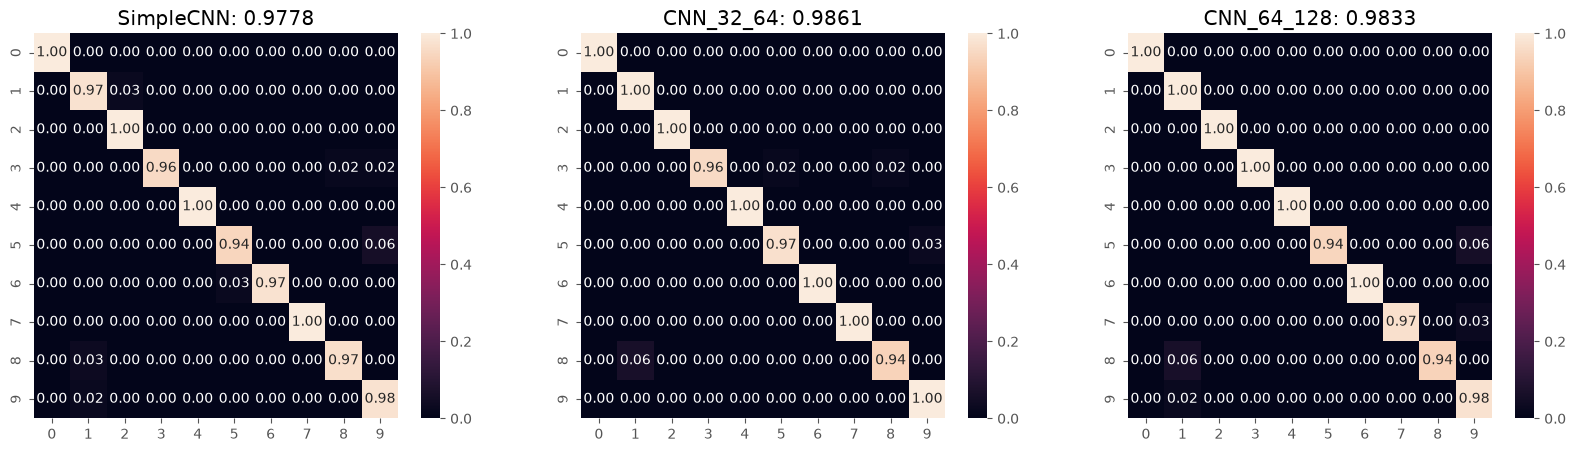

In [12]:
compare_models((model_cnn1, model_cnn2, model_cnn3), test_loader, fig_size=(20,5))

# Fashion MNIST
Okay, so we are honing in on the best performance for the digits data. But, we really need something a bit bigger to work on. Enter: Fashion MNIST. We have already used this dataset in the past, where we got about 84% accuracy with our custom MLP. Lets see how well Keras and tensorflow can perform!

Now let's load in a more diverse, harder to classify dataset: Fashion MNIST
https://www.kaggle.com/zalando-research/fashionmnist

**Labels**

Each training and test example is assigned to one of the following labels:

- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot 

In [13]:
# more data for handwriting recognition?
# Let's use Raschka's implementation for using the mnist dataset:
# https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
import os
import struct
import numpy as np
# from sklearn.preprocessing import RobustScaler
 
def load_mnist(path, kind='fashion_train', is_test=False):
    """Load MNIST data from `path`"""
    labels_path = os.path.join(path, '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', lbpath.read(8))
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)
        
    # Let's start by fixing the sizes, channels last and normalizing
    images = images/255.0
    images = np.expand_dims(images.reshape((-1,28,28)), axis=1)
    # the image data has been resized to (samples, image_channels, image_rows, image_cols)
    
    # and one hot encoding the output values
    NUM_CLASSES = 10

    if not is_test:
        return DataLoader(OneHotDataset(images, labels, NUM_CLASSES), batch_size=64, shuffle=True, pin_memory=False)
    else:
        return DataLoader(OneHotDataset(images, labels, NUM_CLASSES), batch_size=64, shuffle=False, pin_memory=False)
        

train_loader = load_mnist('data/', kind='fashion_train')
test_loader = load_mnist('data/', kind='fashion_t10k', is_test=True)

In [14]:
%%time

model_mlp = ImageMLP(in_features=28*28, hidden_dim=128, num_classes=10).to(device)
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)
train_model(model_mlp, train_loader, test_loader, criterion, optimizer, epochs=10, print_every=1)


Epoch 1 Loss: 0.5643 Test Accuracy: 0.8459
Epoch 2 Loss: 0.3893 Test Accuracy: 0.8582
Epoch 3 Loss: 0.3479 Test Accuracy: 0.8603
Epoch 4 Loss: 0.3229 Test Accuracy: 0.8751
Epoch 5 Loss: 0.3064 Test Accuracy: 0.8722
Epoch 6 Loss: 0.2914 Test Accuracy: 0.8778
Epoch 7 Loss: 0.2787 Test Accuracy: 0.8811
Epoch 8 Loss: 0.2667 Test Accuracy: 0.8766
Epoch 9 Loss: 0.2568 Test Accuracy: 0.8799
Epoch 10 Loss: 0.2456 Test Accuracy: 0.8745
CPU times: user 8.74 s, sys: 1.96 s, total: 10.7 s
Wall time: 12.9 s


{'train_loss': [0.564317136049779,
  0.3893273991784816,
  0.34788714164991114,
  0.3228982943000951,
  0.30644964019277454,
  0.2913781548026147,
  0.27868003258382334,
  0.266660540938568,
  0.256821619128304,
  0.24563625576431308],
 'test_loss': [0.43246070945718484,
  0.3942553527226114,
  0.39218255896477183,
  0.3552990632641847,
  0.3516449409115846,
  0.3464180960966523,
  0.338489676926546,
  0.34494090317540865,
  0.33418738424398337,
  0.346916379537552],
 'test_acc': [0.8459,
  0.8582,
  0.8603,
  0.8751,
  0.8722,
  0.8778,
  0.8811,
  0.8766,
  0.8799,
  0.8745]}

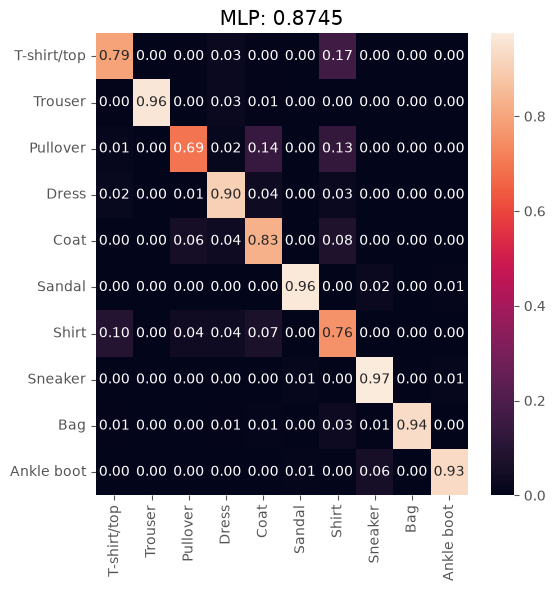

In [15]:
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
compare_models([model_mlp], test_loader, fig_size=(6,6), labels=labels)


In [16]:
%%time

cnn1 = ImageCNNCustom(name = 'FashionConvSmall',
                        input_shape            = [1,28,28],
                        filters_per_conv_layer = [32,32], 
                        dense_layer_size       = 64,
                        use_dropout            = False, 
                        ).to(device)

cnn2 = ImageCNNCustom(name = 'FashionConvLarge',
                        input_shape            = [1,28,28],
                        filters_per_conv_layer = [32,64], 
                        dense_layer_size       = 128,
                        use_dropout            = True, 
                        ).to(device)

for model in [cnn1,cnn2]:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = train_model(model, train_loader, test_loader, criterion, optimizer, epochs=15, print_every=2)



Epoch 1 Loss: 0.4981 Test Accuracy: 0.8656
Epoch 3 Loss: 0.2778 Test Accuracy: 0.8877
Epoch 5 Loss: 0.2244 Test Accuracy: 0.9047
Epoch 7 Loss: 0.1916 Test Accuracy: 0.9128
Epoch 9 Loss: 0.1625 Test Accuracy: 0.9152
Epoch 11 Loss: 0.1407 Test Accuracy: 0.9093
Epoch 13 Loss: 0.1191 Test Accuracy: 0.9107
Epoch 15 Loss: 0.1005 Test Accuracy: 0.9164
Epoch 1 Loss: 0.6173 Test Accuracy: 0.8577
Epoch 3 Loss: 0.3703 Test Accuracy: 0.8903
Epoch 5 Loss: 0.3127 Test Accuracy: 0.9013
Epoch 7 Loss: 0.2827 Test Accuracy: 0.9111
Epoch 9 Loss: 0.2629 Test Accuracy: 0.9131
Epoch 11 Loss: 0.2443 Test Accuracy: 0.9168
Epoch 13 Loss: 0.2324 Test Accuracy: 0.9199
Epoch 15 Loss: 0.2182 Test Accuracy: 0.9160
CPU times: user 36.7 s, sys: 8.91 s, total: 45.6 s
Wall time: 56 s


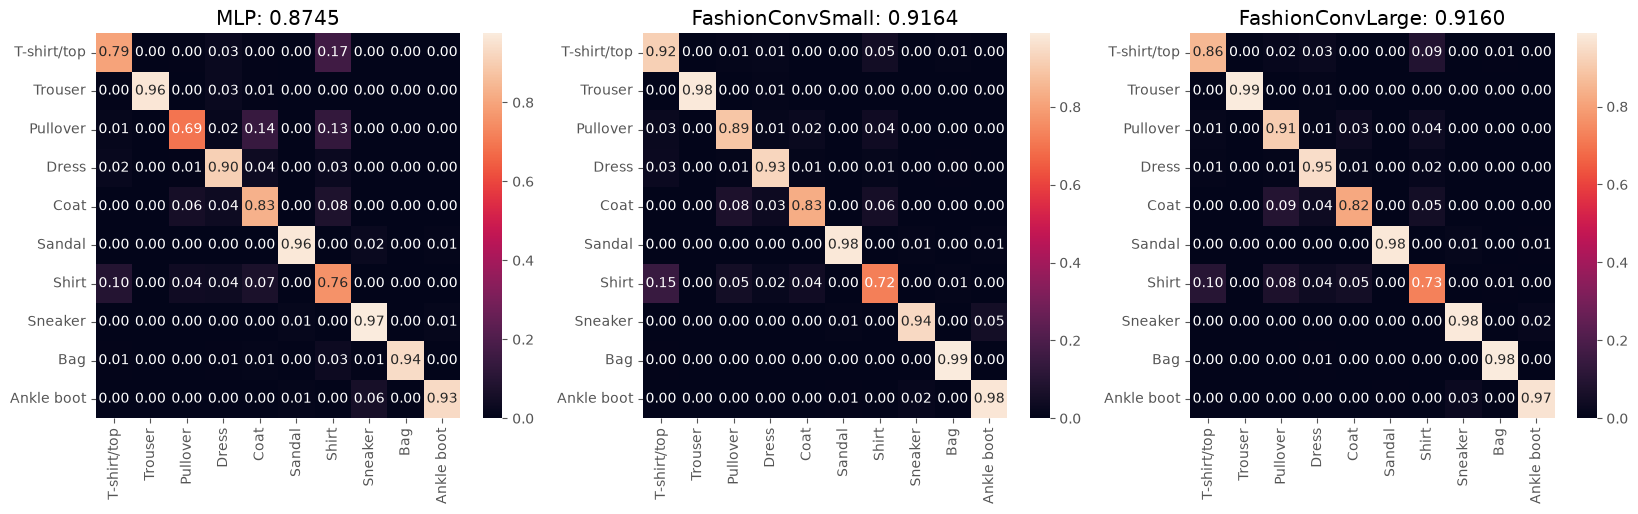

In [17]:
compare_models((model_mlp,cnn1,cnn2), test_loader, fig_size=(20,5), labels=labels)

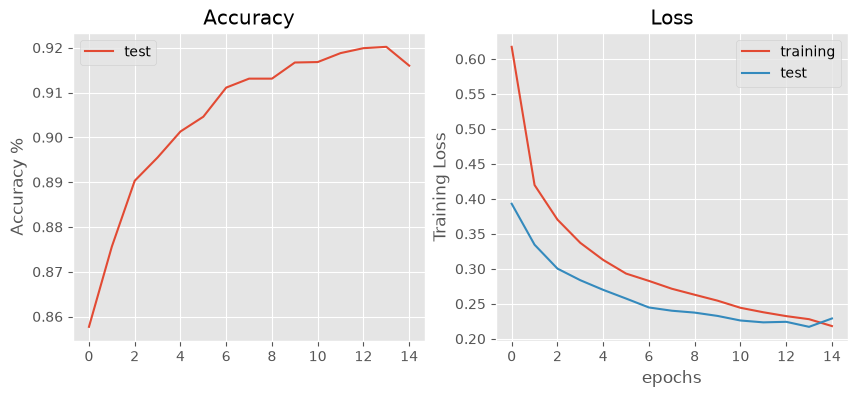

In [18]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.ylabel('Accuracy %')
plt.plot(history['test_acc'], label='test')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_loss'], label='training')
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.plot(history['test_loss'], label='test')
plt.xlabel('epochs')
plt.title('Loss')
plt.legend()
plt.show()

In [19]:
# saving and loading models

# save the model, along with any state variables
torch.save(cnn2.state_dict(), 'large_data/mnist_cnn.pt')


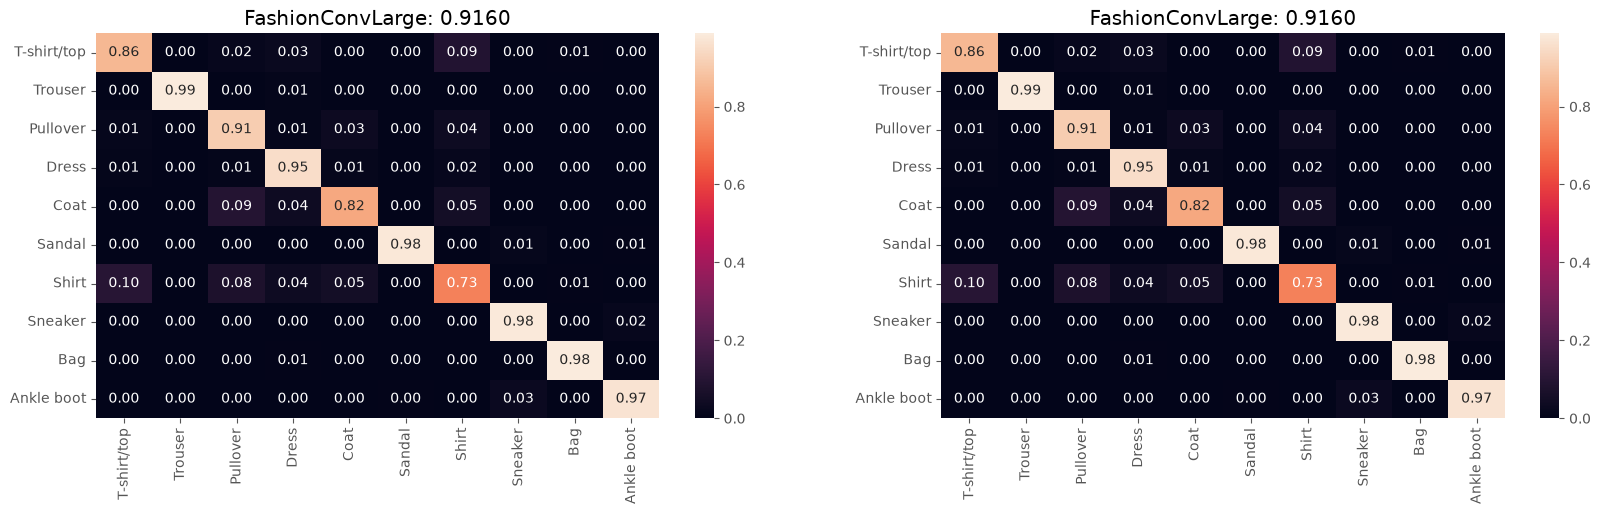

In [20]:
# for loading, we need to create the model first (without the weights trained)
state_dict = torch.load(
    'large_data/mnist_cnn.pt',
    map_location=device,  # Maps directly to target device (e.g., mps, cpu, cuda)
    weights_only=True     # prevents arbitrary code execution
)
# we MUST know the architecture to load from state 
loaded_model = ImageCNNCustom(name = 'FashionConvLarge',
                        input_shape            = [1,28,28],
                        filters_per_conv_layer = [32,64], 
                        dense_layer_size       = 128,
                        use_dropout            = True, 
                        ).to(device)

loaded_model.load_state_dict(state_dict)


# should be identical
compare_models((cnn2, loaded_model), test_loader, fig_size=(20,5), labels=labels)

Epoch 1 Loss: 0.2173 Test Accuracy: 0.9220
Epoch 3 Loss: 0.2052 Test Accuracy: 0.9211
Epoch 5 Loss: 0.1977 Test Accuracy: 0.9220
Epoch 7 Loss: 0.1941 Test Accuracy: 0.9249
Epoch 9 Loss: 0.1888 Test Accuracy: 0.9220
Epoch 10 Loss: 0.1837 Test Accuracy: 0.9238


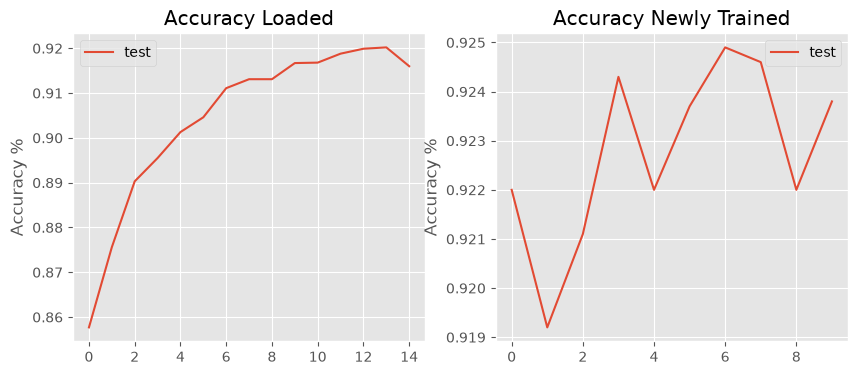

In [21]:
# Can also save more than just the model, like this: 
checkpoint = {
    "epoch": 15,
    "model_state_dict": cnn2.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
}
torch.save(checkpoint, 'large_data/cnn2_checkpoint.pt')

# Now create everything again 
loaded_model = ImageCNNCustom(name = 'FashionConvLarge',
                        input_shape            = [1,28,28],
                        filters_per_conv_layer = [32,64], 
                        dense_layer_size       = 128,
                        use_dropout            = True, 
                        ).to(device)
loaded_optimizer = optim.Adam(loaded_model.parameters(), lr=1e-3)

# and load it in using state tracking 
loaded_checkpoint = torch.load('large_data/cnn2_checkpoint.pt', map_location=device, weights_only=False)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Now we can continue training if we want
history = train_model(loaded_model, train_loader, test_loader, criterion, loaded_optimizer, epochs=10, print_every=2)

loaded_history = checkpoint["history"]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.ylabel('Accuracy %')
plt.plot(loaded_history['test_acc'], label='test')
plt.title('Accuracy Loaded')
plt.legend()

plt.subplot(1,2,2)
plt.ylabel('Accuracy %')
plt.plot(history['test_acc'], label='test')
plt.title('Accuracy Newly Trained')
plt.legend()

plt.show()

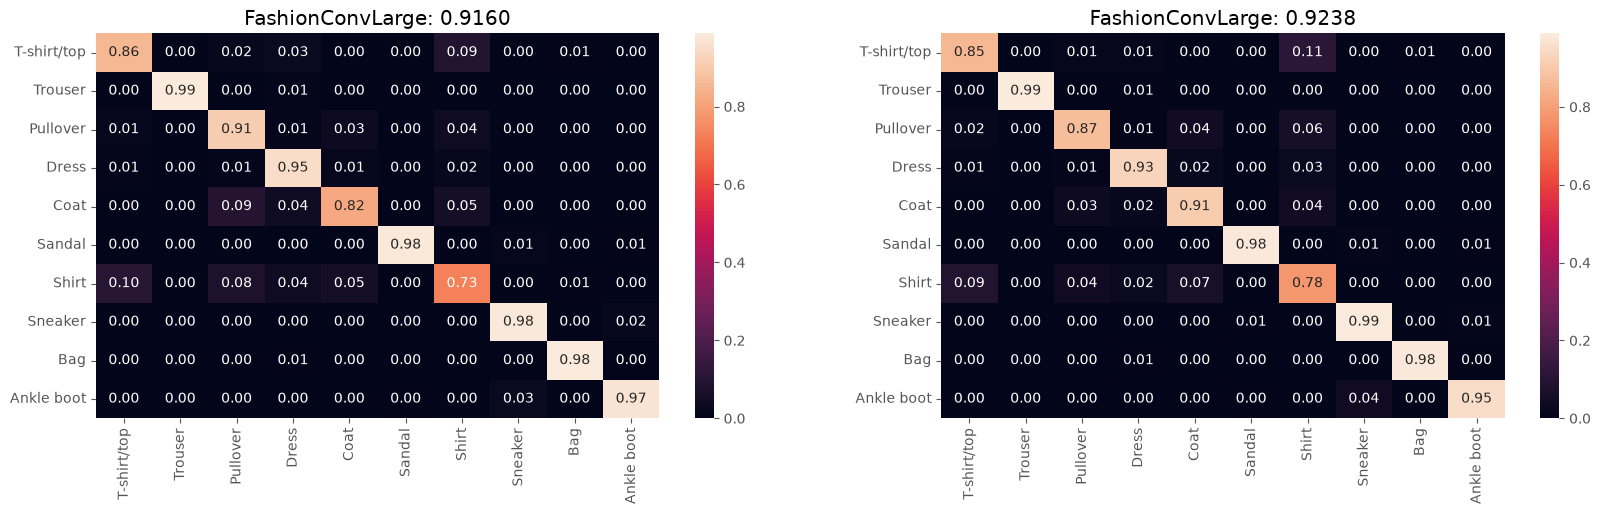

In [22]:
compare_models((cnn2, loaded_model), test_loader, fig_size=(20,5), labels=labels)

______
In this notebook you learned:
 - Basic structure of building a keras sequential model
 - Building different CNN structures
 - Evaluating models with Keras and Sklearn
 - Tuning models, if desired for additional epochs
 - Saving and loading models in keras, with saved optimizer 